## Preparando los Datos para el "Examen" el entrenamiento ML 🦾🧠

Para predecir si un producto si se va agotar (stock_indicator), el algoritmo de **Random Forest** necesita que le demos "pistas" en forma de numeros. Aqui es donde vamos a tomar las variables del clima, los dias de la semana y si hubo promocion y las vamos a traducir a ceros y unos para que el modelo pueda "estudiar".

In [4]:
#================================================
# PASO 1. PREPARACIÓN DE DATOS (TRAIN/TEST SPLIT)
#================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('ggplot')
sns.set_theme(style='darkgrid')

# 1. Cargamos el dataset
df = pd.read_csv('/content/walmart_ml_ready.csv')
print("✅ Dataset cargado")

#==============================
# FASE 1. FEATURES ENGINEERING
#==============================
print("🛠 1. Creando nuevas variables (Feature Engineering)...")

# Ratio de salud: ¿Que tan cerca estamos del punto de reorden? (Si es < 1, peligro )
df['inventory_health_ratio'] = df['inventory_level'] / df['reorder_point']

# Demanda de espera: ¿Cuánto venderemos mientras llega el proveedor?
df['lead_time_demand'] = df['quantity_sold'] * df['supplier_lead_time']

# Margen crítico: Si esto es negativo, nos quedamos sin stock antes de que llegue el camión
df['critical_stock_margin'] = df['inventory_level'] - df['lead_time_demand']

# Pistas para el módelo
columnas_pistas = [
    'inventory_level', 'reorder_point', 'supplier_lead_time', 'quantity_sold',
    'weather_conditions', 'weekday', 'promotion_applied',
    'inventory_health_ratio', 'lead_time_demand', 'critical_stock_margin'
]

# Convertimos en números y partimos los datos
X = pd.get_dummies(df[columnas_pistas], drop_first=True)
y = df['stockout_indicator']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


✅ Dataset cargado
🛠 1. Creando nuevas variables (Feature Engineering)...


🧠🦾 2. Buscando la mejor configuración del Random Forest... (esto tomará unos 30-60 segs)
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✨👌 El modelo campeón ha sido encontrado 🏆
Mejores configuraciones encontradas: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 30}
Mejor puntuación de validación cruzada: 0.5134996267807582

✅ Boleta de calificaciones: 

              precision    recall  f1-score   support

       False       0.49      0.39      0.44       499
        True       0.50      0.59      0.54       501

    accuracy                           0.49      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.49      0.49      0.49      1000



/tmp/ipykernel_8510/3921965671.py:47: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


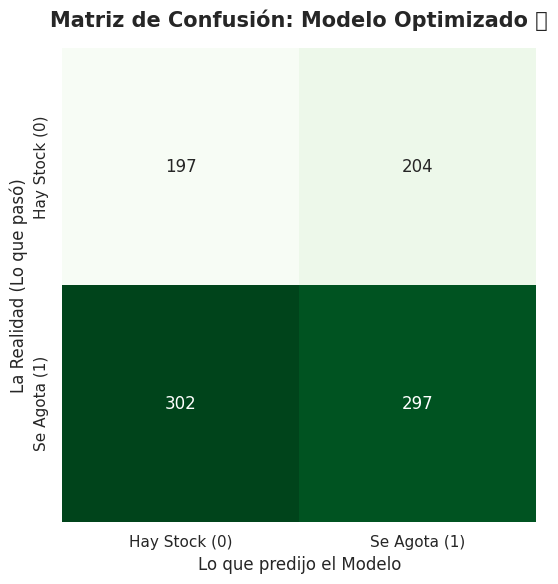

In [5]:
#===========================================
# FASE 2. HYPERPARAMETER TUNING (Esteroides)
#===========================================
print("🧠🦾 2. Buscando la mejor configuración del Random Forest... (esto tomará unos 30-60 segs)")

# La "receta" de configuraciones a probar
param_grid = {
    'n_estimators': [100, 200, 300],          # Cuántos árboles plantar
    'max_depth': [None, 10, 20, 30],          # Qué tan profundos (para que no memoricen)
    'min_samples_split': [2, 5, 10],          # Reglas para crear ramas
}

# Búsqueda aleatoria del mejor modelo (Cross Validation)
rf_base = RandomForestClassifier(random_state=42, n_jobs=1)
rf_optimizado = RandomizedSearchCV(
    estimator=rf_base, param_distributions=param_grid,
    n_iter=10, cv=3, verbose=1, random_state=42, n_jobs=1)

# 🧠🦾Entrenando el modelo
rf_optimizado.fit(X_train, y_train)

print("\n✨👌 El modelo campeón ha sido encontrado 🏆")
print(f"Mejores configuraciones encontradas: {rf_optimizado.best_params_}")
print(f"Mejor puntuación de validación cruzada: {rf_optimizado.best_score_}")

#=========================
# FASE 3. EL EXAMEN FINAL
#=========================
mejor_modelo = rf_optimizado.best_estimator_
predicciones = mejor_modelo.predict(X_test)

print("\n✅ Boleta de calificaciones: \n")
print(classification_report(y_test, predicciones))


# Graficamos la Matriz de confusión
matriz = confusion_matrix(y_test, predicciones)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz.T, square=True, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Hay Stock (0)', 'Se Agota (1)'],
            yticklabels=['Hay Stock (0)', 'Se Agota (1)'])

plt.title('Matriz de Confusión: Modelo Optimizado 🚀', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Lo que predijo el Modelo', fontsize=12)
plt.ylabel('La Realidad (Lo que pasó)', fontsize=12)
plt.tight_layout()
plt.show()